# 📊 Project 2: Exploratory Data Analysis (EDA)

---
## Block 1 — Import Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style settings for clean, professional plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


---
## Block 2 — Load & Inspect the Data

In [46]:
df = pd.read_csv(r'C:\Users\ysyzy\.ipynb_checkpoints\decode_intern\data_cleaning_p\cleaned_file.csv')

# Convert date column to datetime format so we can do time-based analysis later
df['date'] = pd.to_datetime(df['date'])

print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\n--- Column Data Types ---')
print(df.dtypes)
print('\n--- First 5 Rows ---')
df.head()

Dataset Shape: 1200 rows × 17 columns

--- Column Data Types ---
order_id                    object
date                datetime64[ns]
customer_id                 object
product                     object
quantity                     int64
unit_price                 float64
shipping_address            object
payment_method              object
order_status                object
tracking_number             object
items_in_cart                int64
coupon_code                 object
referral_source             object
gross_total                float64
discount_rate              float64
discount_amount            float64
net_total                  float64
dtype: object

--- First 5 Rows ---


,order_id,date,customer_id,product,quantity,unit_price,shipping_address,payment_method,order_status,tracking_number,items_in_cart,coupon_code,referral_source,gross_total,discount_rate,discount_amount,net_total
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,0.1,285.31,2567.79
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,0.1,30.27,272.43
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,0.0,0.00,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,0.1,27.32,245.87
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,0.1,250.40,2253.64


In [47]:
# Check for missing values — important to confirm the data is clean
missing = df.isnull().sum()
print('--- Missing Values Per Column ---')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

--- Missing Values Per Column ---
order_id            0
date                0
customer_id         0
product             0
quantity            0
unit_price          0
shipping_address    0
payment_method      0
order_status        0
tracking_number     0
items_in_cart       0
coupon_code         0
referral_source     0
gross_total         0
discount_rate       0
discount_amount     0
net_total           0
dtype: int64

Total missing values: 0


---
## Block 3 — Descriptive Statistics

In [48]:
numeric_cols = ['quantity', 'unit_price', 'items_in_cart', 'gross_total', 'discount_amount', 'net_total']

print('--- Five-Number Summary for Numeric Columns ---')
df[numeric_cols].describe().round(2)

--- Five-Number Summary for Numeric Columns ---


,quantity,unit_price,items_in_cart,gross_total,discount_amount,net_total
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97,63.21,990.75
std,1.41,197.18,2.28,819.86,99.57,774.94
min,1.00,11.39,1.00,11.39,0.00,9.68
25%,2.00,186.06,4.00,410.52,0.00,384.92
50%,3.00,364.21,5.00,823.62,0.00,766.10
75%,4.00,521.57,7.00,1578.48,93.81,1478.53
max,5.00,699.93,10.00,3456.40,508.62,3390.95


In [49]:
# Manually highlight Mean vs Median for revenue columns
# A big gap here = skewed distribution = outliers likely present

revenue_cols = ['unit_price', 'gross_total', 'net_total']

print(f"{'Column':<20} {'Mean':>10} {'Median':>10} {'Skew':>10}")
print('-' * 52)
for col in revenue_cols:
    mean   = df[col].mean()
    median = df[col].median()
    skew   = df[col].skew()
    print(f"{col:<20} {mean:>10.2f} {median:>10.2f} {skew:>10.3f}")

print()
print('Interpretation: skew > 0 means right-skewed (tail on the right = some very high values)')

Column                     Mean     Median       Skew
----------------------------------------------------
unit_price               356.41     364.21     -0.027
gross_total             1053.97     823.62      0.891
net_total                990.75     766.11      0.911

Interpretation: skew > 0 means right-skewed (tail on the right = some very high values)


---
## Block 4 — Univariate Analysis: Distributions
**What this does:**  
We plot a **histogram + KDE curve** for each numeric column.

- Histogram → shows the frequency of values in buckets (bins)
- KDE (Kernel Density Estimate) → a smooth curve showing the shape of the distribution

**What to look for:**  
- Bell-shaped → normal distribution (mean ≈ median)
- Long right tail → right-skewed (a few very high values)
- Multiple peaks → different groups may exist in the data

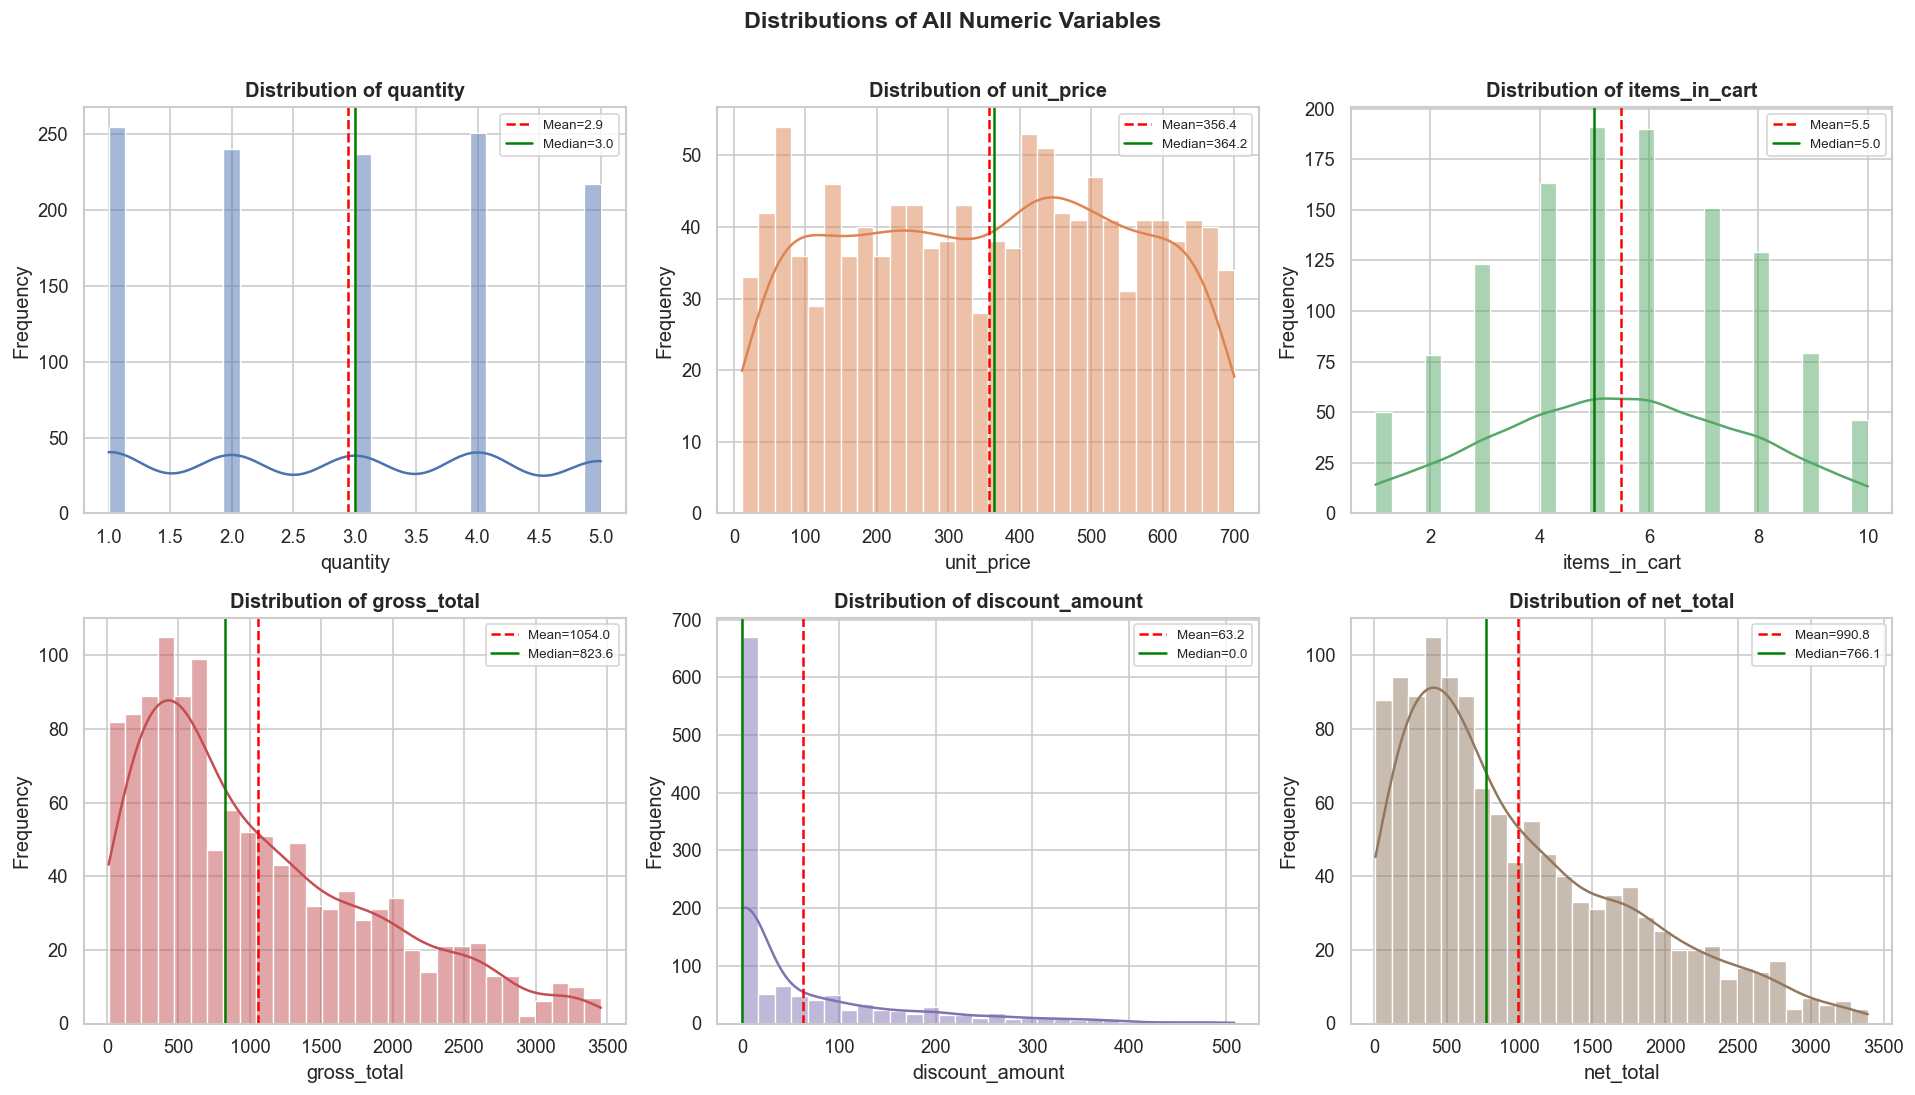

Red dashed = Mean | Green solid = Median


In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i], bins=30)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    # Add vertical lines for mean and median
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green',  linestyle='-',  linewidth=1.5, label=f'Median={df[col].median():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distributions of All Numeric Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()
print('Red dashed = Mean | Green solid = Median')

---
## Block 5 — Categorical Analysis
**What this does:**  
For non-numeric (categorical) columns, we use `.value_counts()` and bar charts to see which categories dominate.

We analyze: Products, Order Status, Referral Source, Payment Method, and Coupon Usage.

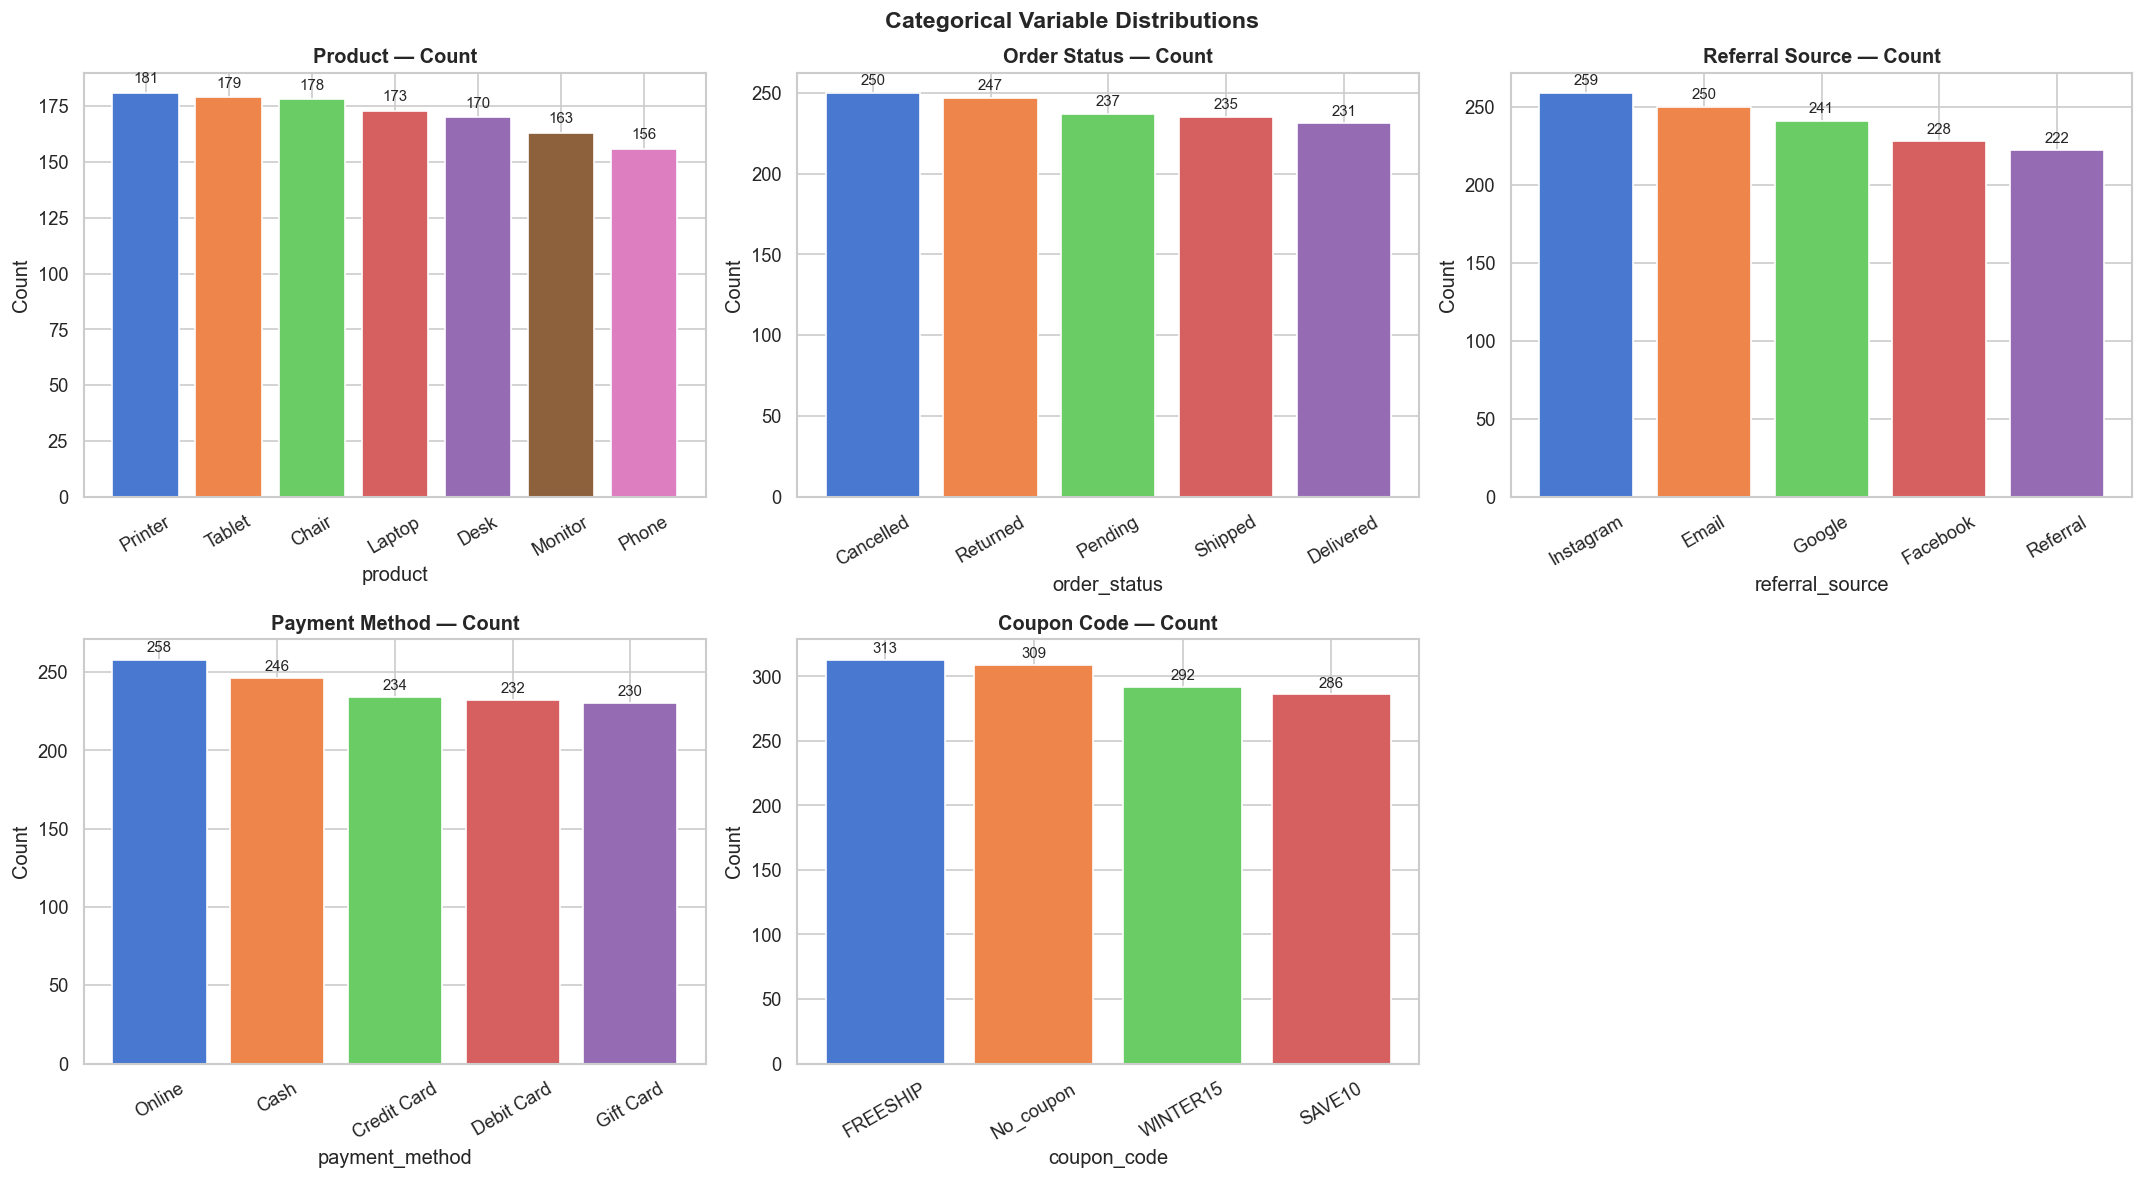

In [51]:
categorical_cols = ['product', 'order_status', 'referral_source', 'payment_method', 'coupon_code']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
    axes[i].set_title(f'{col.replace("_", " ").title()} — Count', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    # Add count labels on top of each bar
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                     str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

axes[5].axis('off')  # hide the 6th empty subplot
plt.suptitle('Categorical Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_analysis.png', bbox_inches='tight')
plt.show()

--- Revenue by Product ---
         Total Revenue  Avg Order Value  Order Count
product                                             
Chair        185379.03          1041.46          178
Printer      183589.54          1014.31          181
Laptop       181126.23          1046.97          173
Tablet       173930.29           971.68          179
Monitor      163429.13          1002.63          163
Desk         157845.41           928.50          170
Phone        143605.74           920.55          156


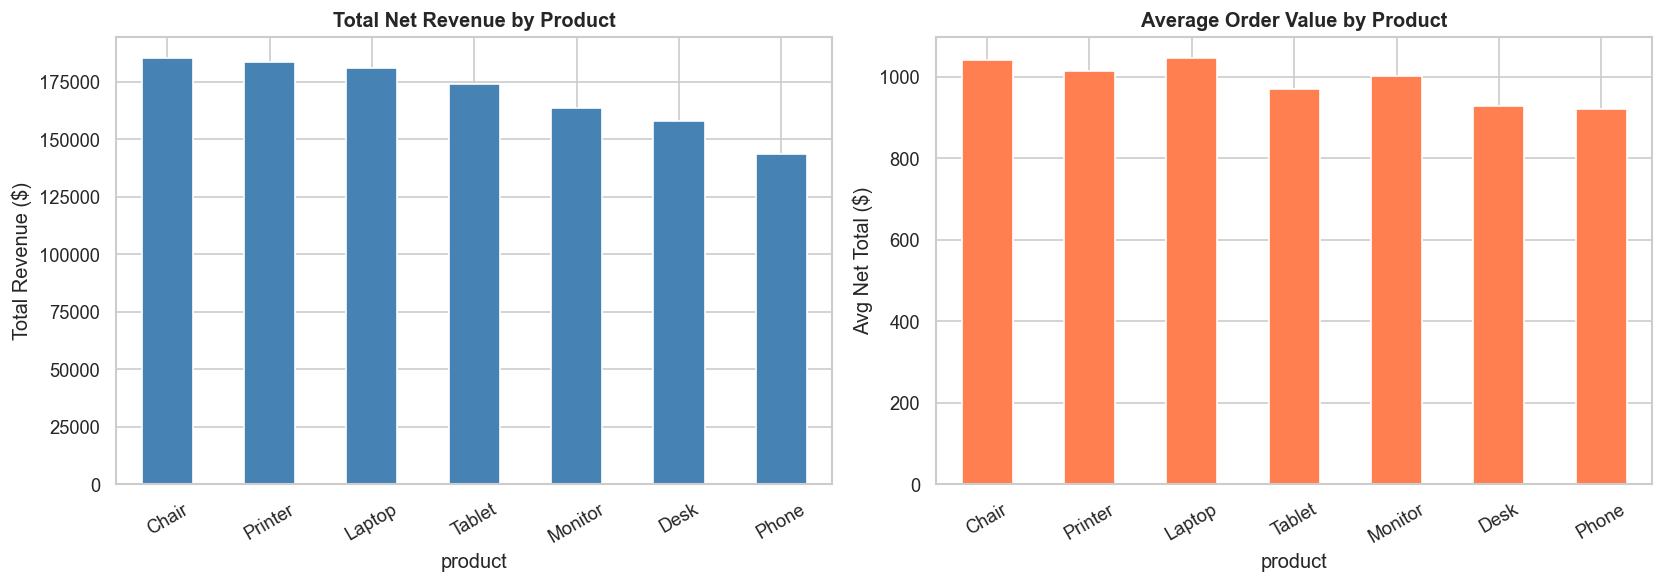

In [52]:
# Revenue breakdown by product — which product earns the most?
# groupby() splits the data by category, then we aggregate with sum/mean

product_revenue = df.groupby('product')['net_total'].agg(['sum', 'mean', 'count']).round(2)
product_revenue.columns = ['Total Revenue', 'Avg Order Value', 'Order Count']
product_revenue = product_revenue.sort_values('Total Revenue', ascending=False)

print('--- Revenue by Product ---')
print(product_revenue)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

product_revenue['Total Revenue'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Total Net Revenue by Product', fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=30)

product_revenue['Avg Order Value'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average Order Value by Product', fontweight='bold')
axes[1].set_ylabel('Avg Net Total ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [53]:
# Order status breakdown — how healthy is fulfillment?
# Cancelled + Returned orders = lost revenue

status_counts = df['order_status'].value_counts()
total = len(df)

print('--- Order Status Breakdown ---')
for status, count in status_counts.items():
    pct = count / total * 100
    print(f'{status:<12}: {count:>4} orders ({pct:.1f}%)')

# Revenue lost to cancellations and returns
lost = df[df['order_status'].isin(['Cancelled', 'Returned'])]['net_total'].sum()
total_revenue = df['net_total'].sum()
print(f'\nRevenue lost to Cancelled + Returned orders: ${lost:,.2f}')
print(f'That is {lost/total_revenue*100:.1f}% of total potential revenue')

--- Order Status Breakdown ---
Cancelled   :  250 orders (20.8%)
Returned    :  247 orders (20.6%)
Pending     :  237 orders (19.8%)
Shipped     :  235 orders (19.6%)
Delivered   :  231 orders (19.2%)

Revenue lost to Cancelled + Returned orders: $488,212.34
That is 41.1% of total potential revenue


---
## Block 6 — Outlier Detection: IQR Method

In [54]:
def detect_outliers_iqr(series):
    """Returns outlier count, percentage, and the fence boundaries."""
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers = series[(series < lower_fence) | (series > upper_fence)]
    return {
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Fence': round(lower_fence, 2),
        'Upper Fence': round(upper_fence, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(series) * 100, 2)
    }

print(f"{'Column':<18} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>8}")
print('-' * 62)
for col in ['unit_price', 'gross_total', 'net_total', 'quantity']:
    result = detect_outliers_iqr(df[col])
    print(f"{col:<18} {result['Lower Fence']:>10} {result['Upper Fence']:>10} "
          f"{result['Outlier Count']:>10} {result['Outlier %']:>8}%")

Column                  Lower      Upper   Outliers        %
--------------------------------------------------------------
unit_price             -317.2    1024.83          0      0.0%
gross_total          -1341.41    3330.41          8     0.67%
net_total            -1255.49    3118.94         13     1.08%
quantity                 -1.0        7.0          0      0.0%


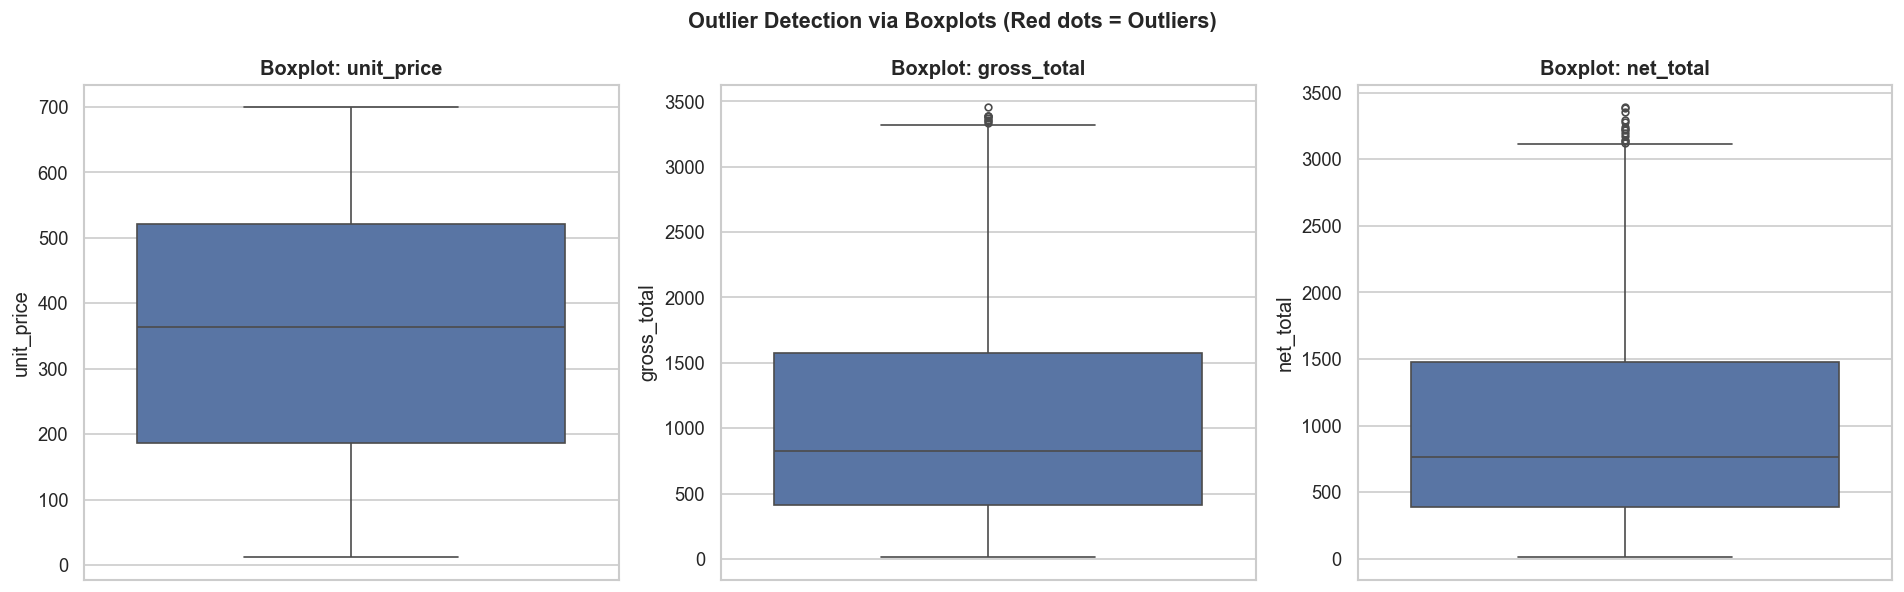

In [ ]:
# Boxplots visually show outliers — dots beyond the whiskers are the suspects

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
outlier_cols = ['unit_price', 'gross_total', 'net_total']

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0', flierprops=dict(marker='o', color='red', markersize=4))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection via Boxplots (Red dots = Outliers)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [56]:
# Show the top 10 highest net_total orders — are these VIP customers or data errors?
# This is the 'Signal vs Noise' question from the slides

top_orders = df.nlargest(10, 'net_total')[['order_id', 'product', 'quantity', 'unit_price', 'net_total', 'order_status']]
print('--- Top 10 Highest Value Orders ---')
print(top_orders.to_string(index=False))

print(f'\nAverage net_total of top 10: ${top_orders["net_total"].mean():,.2f}')
print(f'Overall average net_total:   ${df["net_total"].mean():,.2f}')

--- Top 10 Highest Value Orders ---
 order_id product  quantity  unit_price  net_total order_status
ORD201122 Monitor         5      678.19    3390.95     Returned
ORD200469   Chair         5      676.98    3384.90    Cancelled
ORD200107 Printer         5      670.75    3353.75      Shipped
ORD200367  Laptop         5      658.77    3293.85      Pending
ORD200837   Chair         5      655.55    3277.75    Delivered
ORD200540  Laptop         5      648.65    3243.25      Pending
ORD200802   Chair         5      644.64    3223.20    Cancelled
ORD200086 Printer         5      643.03    3215.15    Cancelled
ORD200967  Tablet         5      638.92    3194.60     Returned
ORD201079   Phone         5      634.00    3170.00    Delivered

Average net_total of top 10: $3,274.74
Overall average net_total:   $990.75


---
## Block 7 — Trend Analysis: Sales Over Time

In [57]:
# Create a Year-Month column for grouping
df['year_month'] = df['date'].dt.to_period('M')

monthly = df.groupby('year_month').agg(
    total_revenue  = ('net_total', 'sum'),
    order_count    = ('order_id', 'count'),
    avg_order_val  = ('net_total', 'mean')
).reset_index()

monthly['year_month_str'] = monthly['year_month'].astype(str)

print('Monthly Revenue Summary (first 10 months):')
print(monthly[['year_month_str', 'total_revenue', 'order_count', 'avg_order_val']].head(10).to_string(index=False))

Monthly Revenue Summary (first 10 months):
year_month_str  total_revenue  order_count  avg_order_val
       2023-01       52758.52           47    1122.521702
       2023-02       37318.52           37    1008.608649
       2023-03       45642.95           43    1061.463953
       2023-04       25531.13           31     823.584839
       2023-05       60028.80           49    1225.077551
       2023-06       46817.10           45    1040.380000
       2023-07       41408.59           44     941.104318
       2023-08       51960.36           51    1018.830588
       2023-09       27073.68           29     933.575172
       2023-10       48890.97           47    1040.233404


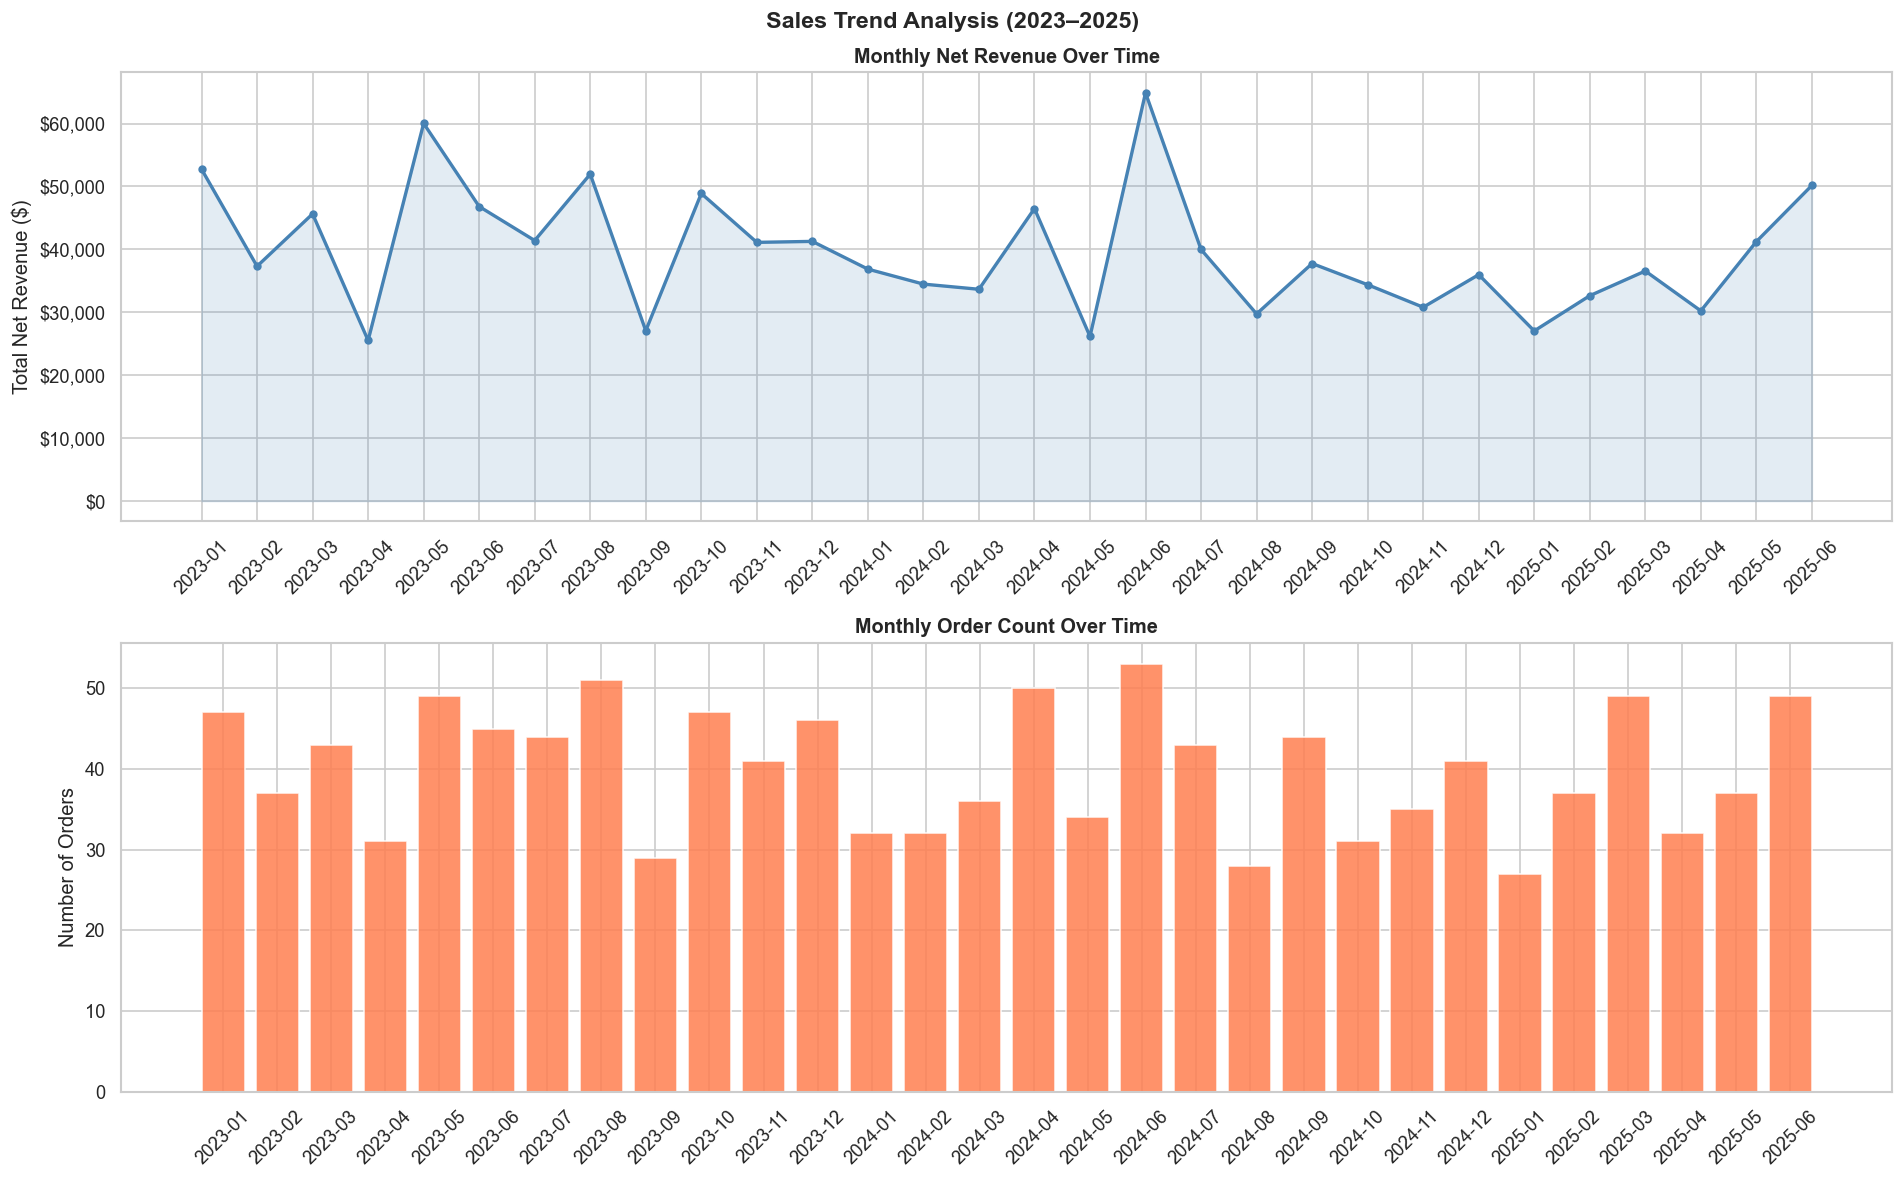

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1 — Monthly total revenue trend
axes[0].plot(monthly['year_month_str'], monthly['total_revenue'],
             marker='o', linewidth=2, color='steelblue', markersize=4)
axes[0].fill_between(monthly['year_month_str'], monthly['total_revenue'], alpha=0.15, color='steelblue')
axes[0].set_title('Monthly Net Revenue Over Time', fontweight='bold')
axes[0].set_ylabel('Total Net Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Plot 2 — Monthly order count trend
axes[1].bar(monthly['year_month_str'], monthly['order_count'],
            color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Monthly Order Count Over Time', fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Sales Trend Analysis (2023–2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

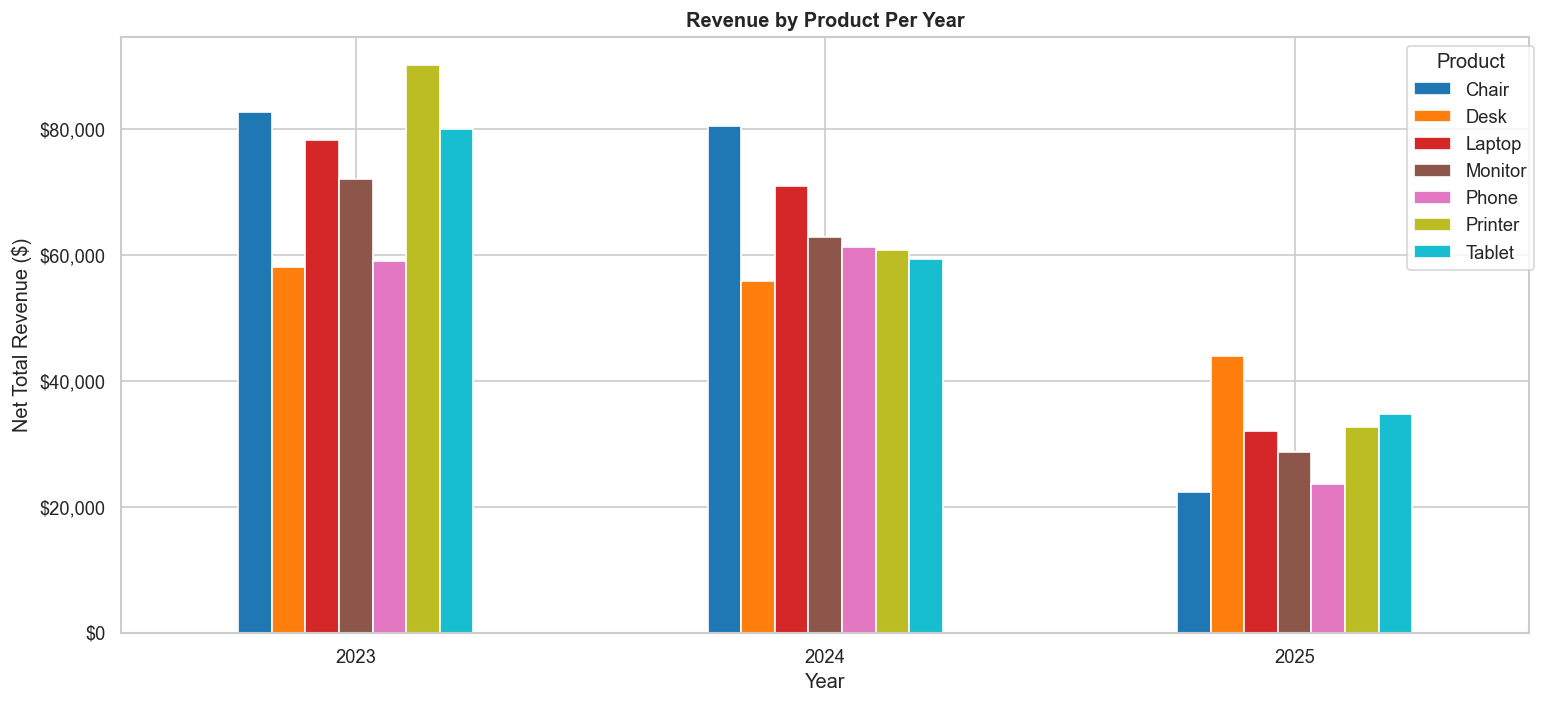

In [ ]:
# Revenue by product over time — which products are growing?

# Add year column for yearly aggregation
df['year'] = df['date'].dt.year

yearly_product = df.groupby(['year', 'product'])['net_total'].sum().unstack()

fig, ax = plt.subplots(figsize=(13, 6))
yearly_product.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Revenue by Product Per Year', fontweight='bold')
ax.set_ylabel('Net Total Revenue ($)')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Product', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

---
## Block 8 — Correlation Analysis
- `+1.0` → perfect positive (both go up together)
- `0.0` → no linear relationship
- `−1.0` → perfect negative (one goes up, the other goes down)

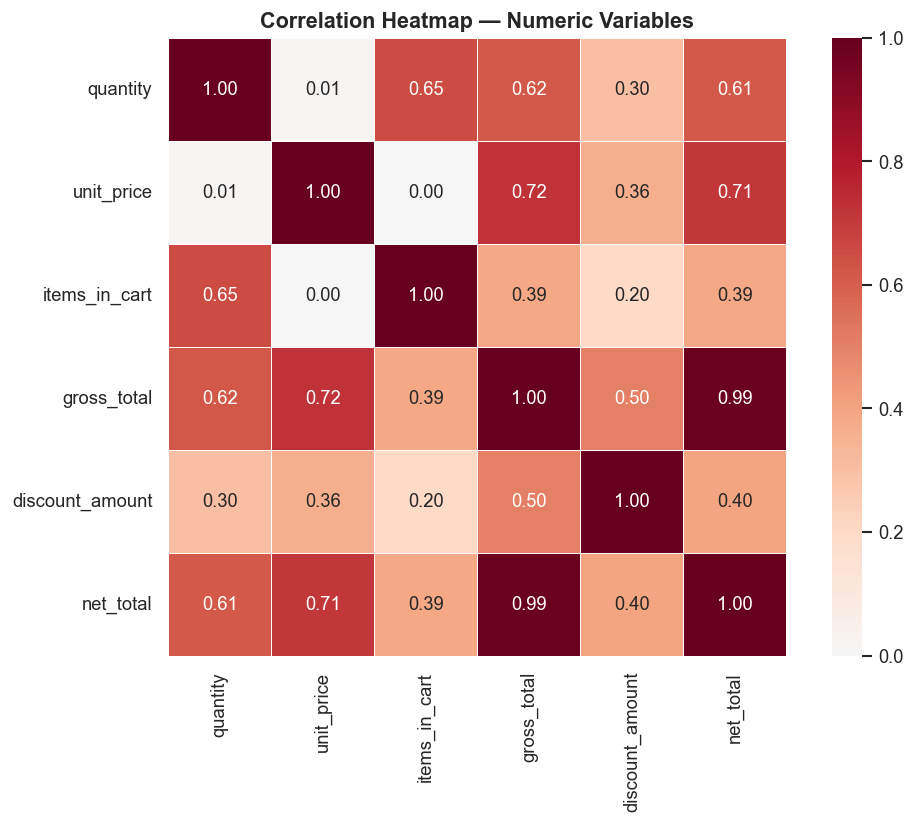

In [60]:
corr_matrix = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,        # show the numbers inside each cell
    fmt='.2f',
    cmap='RdBu_r',     # Red = positive, Blue = negative, White = no correlation
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Heatmap — Numeric Variables', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

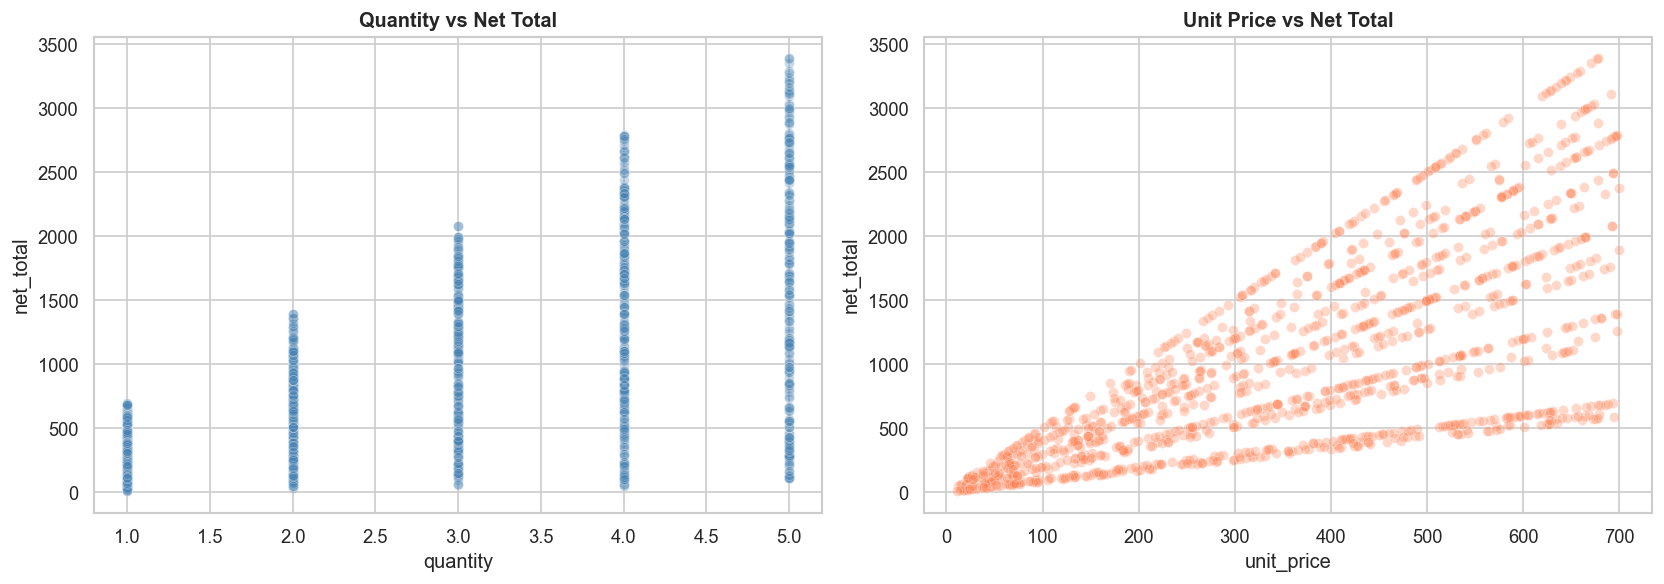

In [ ]:
# Scatter: quantity vs net_total — does ordering more = higher total? (obvious, but let's confirm)
# Scatter: unit_price vs net_total — does a higher price product drive higher totals?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='quantity', y='net_total', alpha=0.3, ax=axes[0], color='steelblue')
axes[0].set_title('Quantity vs Net Total', fontweight='bold')

sns.scatterplot(data=df, x='unit_price', y='net_total', alpha=0.3, ax=axes[1], color='coral')
axes[1].set_title('Unit Price vs Net Total', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Block 9 — Deep Dive: Referral & Coupon Performance
**Business question:** Which marketing channel brings in the highest-value customers?  
**Business question:** Do coupons actually help revenue, or do they just cut into margins?

--- Revenue by Referral Source ---
                 Avg Order Value  Total Revenue  Orders
referral_source                                        
Facebook                 1037.08      236454.85     228
Instagram                 997.79      258428.57     259
Email                     986.67      246668.25     250
Google                    972.70      234420.70     241
Referral                  959.16      212933.00     222


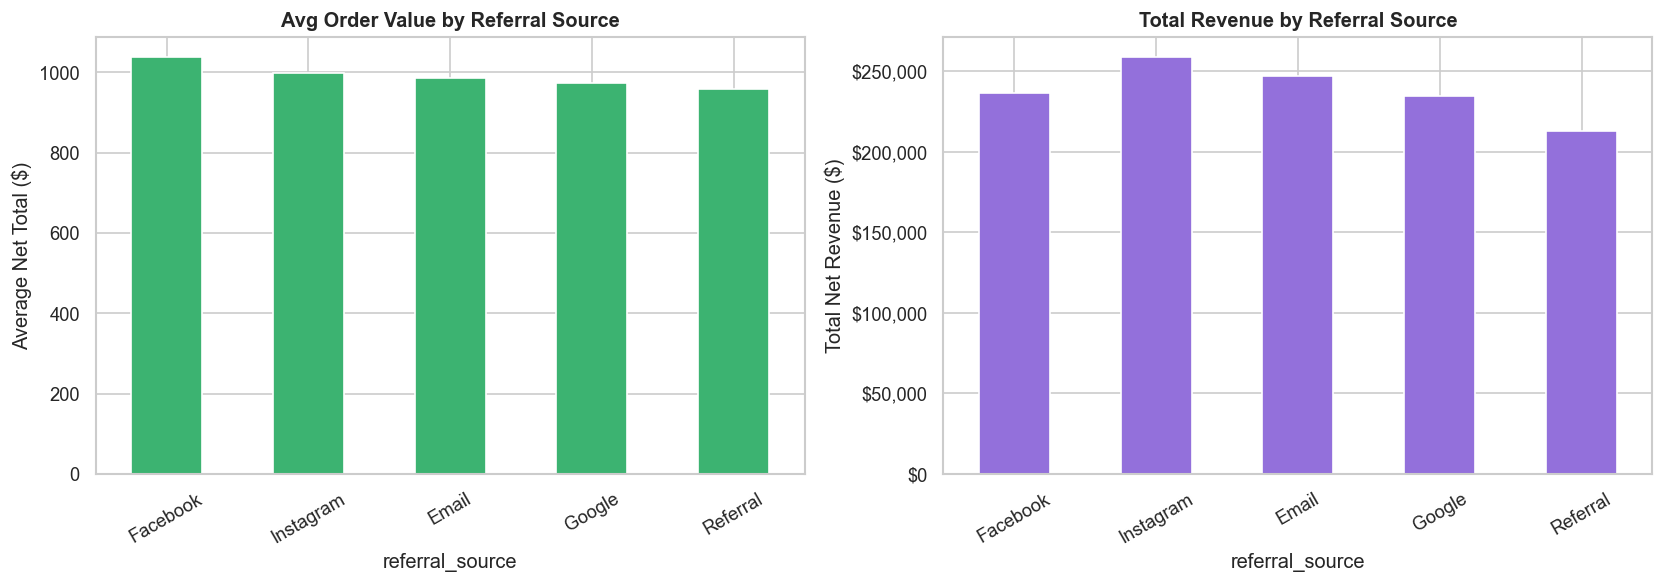

In [62]:
# Average net revenue per referral source
referral_rev = df.groupby('referral_source')['net_total'].agg(['mean', 'sum', 'count']).round(2)
referral_rev.columns = ['Avg Order Value', 'Total Revenue', 'Orders']
referral_rev = referral_rev.sort_values('Avg Order Value', ascending=False)
print('--- Revenue by Referral Source ---')
print(referral_rev)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

referral_rev['Avg Order Value'].plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Avg Order Value by Referral Source', fontweight='bold')
axes[0].set_ylabel('Average Net Total ($)')
axes[0].tick_params(axis='x', rotation=30)

referral_rev['Total Revenue'].plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Total Revenue by Referral Source', fontweight='bold')
axes[1].set_ylabel('Total Net Revenue ($)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('referral_analysis.png', bbox_inches='tight')
plt.show()

--- Coupon Code Performance ---
             orders  avg_gross  avg_discount  avg_net  total_discount
coupon_code                                                          
FREESHIP        313    1070.41          0.00  1070.41            0.00
No_coupon       309    1043.37          0.00  1043.37            0.00
SAVE10          286    1065.87        106.59   959.29        30484.06
WINTER15        292    1035.90        155.39   880.52        45372.53


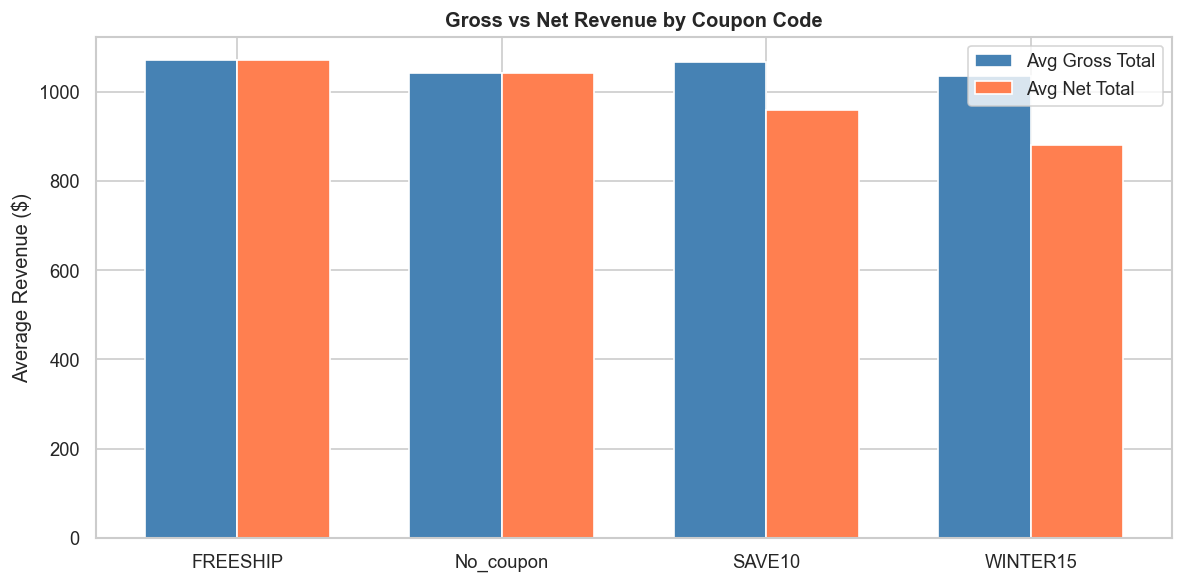

In [63]:
# Coupon code analysis — do discounts generate higher revenue or lose money?

coupon_analysis = df.groupby('coupon_code').agg(
    orders          = ('order_id', 'count'),
    avg_gross       = ('gross_total', 'mean'),
    avg_discount    = ('discount_amount', 'mean'),
    avg_net         = ('net_total', 'mean'),
    total_discount  = ('discount_amount', 'sum')
).round(2)

print('--- Coupon Code Performance ---')
print(coupon_analysis)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(coupon_analysis))
width = 0.35

bars1 = ax.bar(x - width/2, coupon_analysis['avg_gross'], width, label='Avg Gross Total', color='steelblue')
bars2 = ax.bar(x + width/2, coupon_analysis['avg_net'],   width, label='Avg Net Total',   color='coral')

ax.set_title('Gross vs Net Revenue by Coupon Code', fontweight='bold')
ax.set_ylabel('Average Revenue ($)')
ax.set_xticks(x)
ax.set_xticklabels(coupon_analysis.index)
ax.legend()
plt.tight_layout()
plt.savefig('coupon_analysis.png', bbox_inches='tight')
plt.show()

---
## Block 10 — Key Observations & Business Insights

In [64]:
# ─── Compute all insight numbers ───────────────────────────────────────────

total_orders       = len(df)
total_revenue      = df['net_total'].sum()
avg_order_value    = df['net_total'].mean()
median_order_value = df['net_total'].median()

cancelled_pct  = (df['order_status'] == 'Cancelled').mean() * 100
returned_pct   = (df['order_status'] == 'Returned').mean()  * 100
problem_pct    = cancelled_pct + returned_pct

lost_revenue   = df[df['order_status'].isin(['Cancelled', 'Returned'])]['net_total'].sum()

top_product    = df.groupby('product')['net_total'].sum().idxmax()
top_referral   = df.groupby('referral_source')['net_total'].mean().idxmax()
best_coupon    = df.groupby('coupon_code')['net_total'].mean().idxmax()

total_discount_given = df['discount_amount'].sum()

# ─── Print the executive summary ──────────────────────────────────────────

print('=' * 65)
print('          EXECUTIVE SUMMARY — EDA FINDINGS')
print('=' * 65)

print(f'''
DATASET OVERVIEW
  Total Orders Analyzed : {total_orders:,}
  Date Range            : {df['date'].min().date()} → {df['date'].max().date()}
  Total Net Revenue     : ${total_revenue:,.2f}

CENTRAL TENDENCY
  Mean Order Value      : ${avg_order_value:,.2f}
  Median Order Value    : ${median_order_value:,.2f}
  → Mean > Median means revenue is right-skewed.
    A few high-value orders pull the average up.
    Median is the better "typical" order value.

ORDER STATUS (CRITICAL)
  Cancelled Orders      : {cancelled_pct:.1f}%
  Returned Orders       : {returned_pct:.1f}%
  Combined Problem Rate : {problem_pct:.1f}% of all orders
  Revenue at Risk       : ${lost_revenue:,.2f}
  → Nearly 1 in 2 orders has a problem (cancelled or returned).
    This is the #1 priority for the business to investigate.

PRODUCT PERFORMANCE
  Highest Revenue Product : {top_product}
  → Focus upselling and inventory on this product.

MARKETING CHANNELS
  Best Avg Order Value    : {top_referral} channel
  → Invest more in this channel for higher-quality customers.

DISCOUNT STRATEGY
  Total Discounts Given   : ${total_discount_given:,.2f}
  Best Performing Coupon  : {best_coupon}
  → Evaluate if discounts are driving enough volume to offset margin loss.
''')
print('=' * 65)

          EXECUTIVE SUMMARY — EDA FINDINGS

DATASET OVERVIEW
  Total Orders Analyzed : 1,200
  Date Range            : 2023-01-01 → 2025-06-30
  Total Net Revenue     : $1,188,905.37

CENTRAL TENDENCY
  Mean Order Value      : $990.75
  Median Order Value    : $766.11
  → Mean > Median means revenue is right-skewed.
    A few high-value orders pull the average up.
    Median is the better "typical" order value.

ORDER STATUS (CRITICAL)
  Cancelled Orders      : 20.8%
  Returned Orders       : 20.6%
  Combined Problem Rate : 41.4% of all orders
  Revenue at Risk       : $488,212.34
  → Nearly 1 in 2 orders has a problem (cancelled or returned).
    This is the #1 priority for the business to investigate.

PRODUCT PERFORMANCE
  Highest Revenue Product : Chair
  → Focus upselling and inventory on this product.

MARKETING CHANNELS
  Best Avg Order Value    : Facebook channel
  → Invest more in this channel for higher-quality customers.

DISCOUNT STRATEGY
  Total Discounts Given   : $75,856

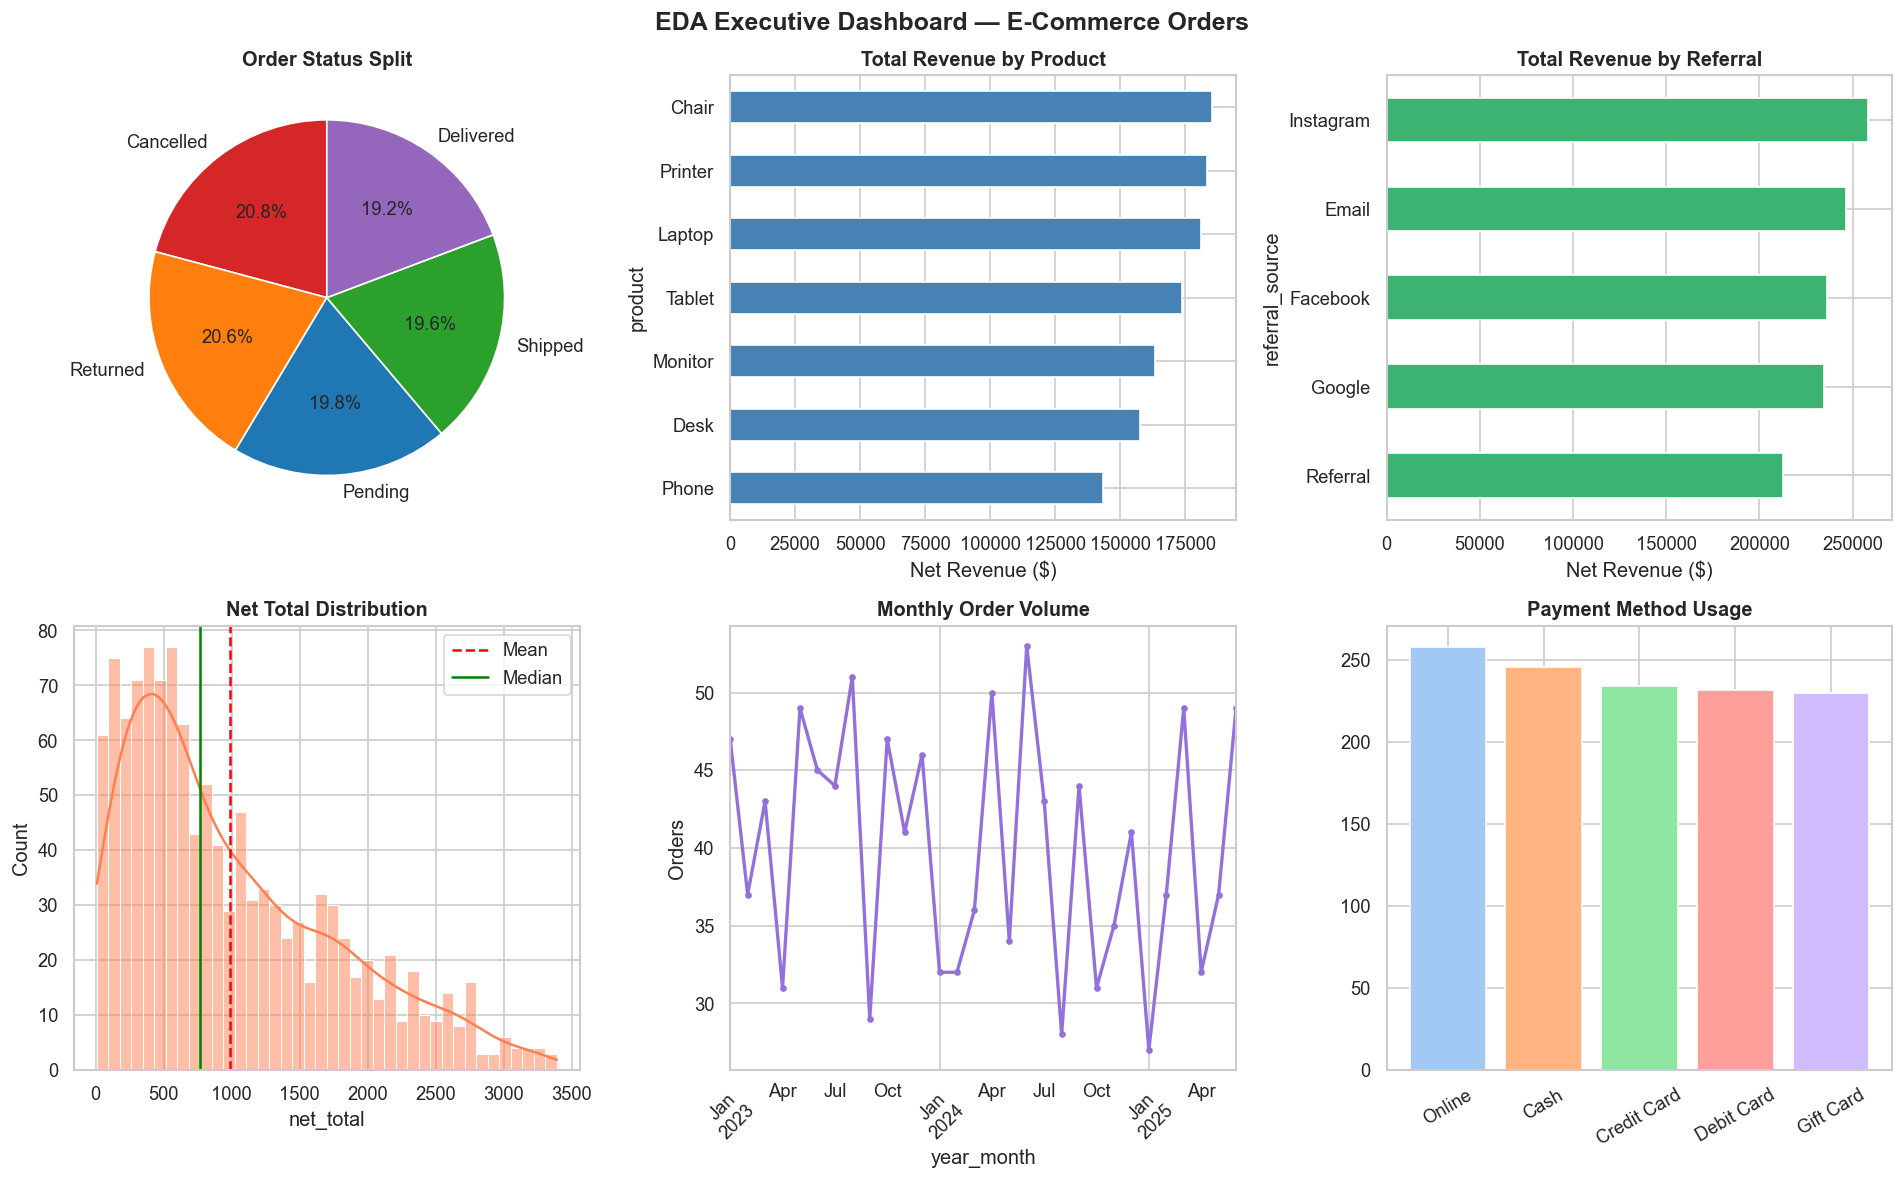

Dashboard saved as eda_dashboard.png ✅


In [65]:
# Final summary visualization — a single dashboard snapshot

fig = plt.figure(figsize=(16, 10))
fig.suptitle('EDA Executive Dashboard — E-Commerce Orders', fontsize=15, fontweight='bold')

# 1. Order Status Pie
ax1 = fig.add_subplot(2, 3, 1)
status_counts = df['order_status'].value_counts()
colors_pie = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c', '#9467bd']
ax1.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90)
ax1.set_title('Order Status Split', fontweight='bold')

# 2. Revenue by Product
ax2 = fig.add_subplot(2, 3, 2)
prod_rev = df.groupby('product')['net_total'].sum().sort_values()
prod_rev.plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Total Revenue by Product', fontweight='bold')
ax2.set_xlabel('Net Revenue ($)')

# 3. Revenue by Referral Source
ax3 = fig.add_subplot(2, 3, 3)
ref_rev = df.groupby('referral_source')['net_total'].sum().sort_values()
ref_rev.plot(kind='barh', ax=ax3, color='mediumseagreen')
ax3.set_title('Total Revenue by Referral', fontweight='bold')
ax3.set_xlabel('Net Revenue ($)')

# 4. Net Total Distribution
ax4 = fig.add_subplot(2, 3, 4)
sns.histplot(df['net_total'], kde=True, ax=ax4, color='coral', bins=40)
ax4.axvline(df['net_total'].mean(),   color='red',   linestyle='--', label='Mean')
ax4.axvline(df['net_total'].median(), color='green', linestyle='-',  label='Median')
ax4.set_title('Net Total Distribution', fontweight='bold')
ax4.legend()

# 5. Monthly Order Count
ax5 = fig.add_subplot(2, 3, 5)
monthly_counts = df.groupby('year_month')['order_id'].count()
monthly_counts.plot(ax=ax5, color='mediumpurple', linewidth=2, marker='o', markersize=3)
ax5.set_title('Monthly Order Volume', fontweight='bold')
ax5.set_ylabel('Orders')
ax5.tick_params(axis='x', rotation=45)

# 6. Payment Method
ax6 = fig.add_subplot(2, 3, 6)
pay_counts = df['payment_method'].value_counts()
ax6.bar(pay_counts.index, pay_counts.values, color=sns.color_palette('pastel', len(pay_counts)))
ax6.set_title('Payment Method Usage', fontweight='bold')
ax6.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard saved as eda_dashboard.png ✅')